# EDA — Cost-Sensitive Predictive Modeling

**Objective**: Identify customers most likely to accept a marketing offer.  
**Scoring**: `Score = TP×10 − FP×5 − NoVariables×200`  (cap: 1 000 contacts)

This notebook explores the raw data before any model fitting:
label distribution, feature variance, covariate shift, class separability, correlations, and calibration baseline.
All plots are saved to `figures/`.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import brier_score_loss
from scipy.stats import spearmanr

from data import load_data
from features import l1_path_ranking, per_feature_ks, covariate_shift_auc

FIGURES = Path('figures')
FIGURES.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

X_train, y_train, X_test, Xs_train, Xs_test, scaler = load_data()
N_TRAIN, N_FEAT = X_train.shape
N_TEST = X_test.shape[0]
print(f'Train: {N_TRAIN} × {N_FEAT}   Test: {N_TEST} × {N_FEAT}')
print(f'Positive rate (train): {y_train.mean():.3f}')

Train: 5000 × 500   Test: 5000 × 500
Positive rate (train): 0.498


## 1. Label Distribution

A near-50/50 split is unusually balanced for a marketing conversion task — it likely reflects deliberate oversampling in the data generation process. This means the model's raw predicted probabilities will be shifted compared to real deployment, but since we evaluate on the same distribution, CV estimates remain valid.

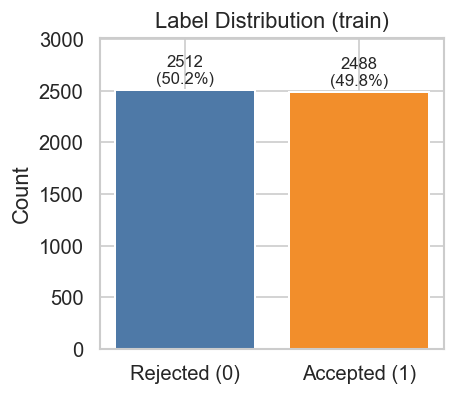

   count  fraction
0   2512    0.5024
1   2488    0.4976


In [2]:
counts = pd.Series(y_train).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4, 3.5))
bars = ax.bar(['Rejected (0)', 'Accepted (1)'], counts.values,
              color=['#4e79a7', '#f28e2b'], edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{v}\n({v/N_TRAIN:.1%})', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, counts.max() * 1.2)
ax.set_ylabel('Count')
ax.set_title('Label Distribution (train)')
plt.tight_layout()
plt.savefig(FIGURES / '01_label_dist.png')
plt.show()

print(pd.DataFrame({'count': counts, 'fraction': counts / N_TRAIN}).to_string())

## 2. Feature Variance Landscape

We examine the standard deviation of every raw feature. Near-zero variance features carry no discriminative power and should be excluded from any model — their only effect is to increase the NoVariables cost.

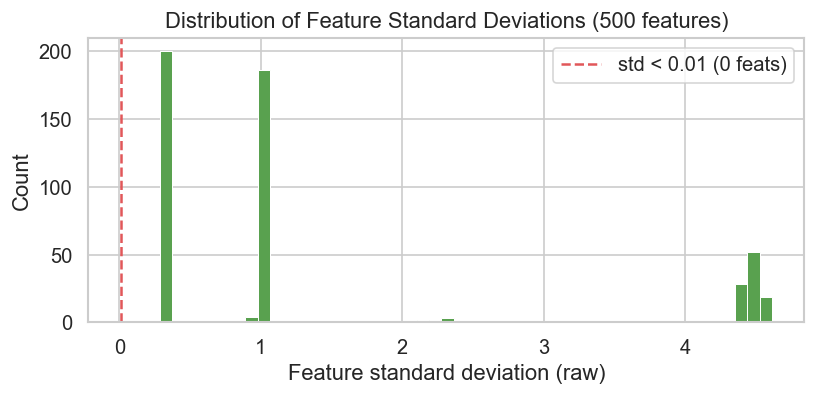

Near-constant features (std < 0.01): 0
std percentiles: p1=0.286  p5=0.287  median=0.993  p95=4.518


In [3]:
feat_std = X_train.std(axis=0)
low_var_thr = 0.01
n_low = int((feat_std < low_var_thr).sum())

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(feat_std, bins=50, color='#59a14f', edgecolor='white', linewidth=0.6)
ax.axvline(low_var_thr, color='#e15759', linestyle='--', label=f'std < {low_var_thr} ({n_low} feats)')
ax.set_xlabel('Feature standard deviation (raw)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Feature Standard Deviations (500 features)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / '02_feat_variance.png')
plt.show()

print(f'Near-constant features (std < {low_var_thr}): {n_low}')
print(f'std percentiles: p1={np.percentile(feat_std,1):.3f}  p5={np.percentile(feat_std,5):.3f}  '
      f'median={np.median(feat_std):.3f}  p95={np.percentile(feat_std,95):.3f}')

## 3. Covariate Shift: Train vs Test

Covariate shift occurs when the feature distribution differs between train and test. We detect it two ways:
1. **Per-feature KS test** — flags individual features that shifted
2. **Discriminator AUC** — fits a classifier to distinguish train vs test; AUC ≈ 0.5 means no detectable shift
3. **PCA projection** — visual overlap of the two sets in 2D

Shifted features are risky: models trained on them may not generalize to the test set.

Computing per-feature KS statistics (500 features)...


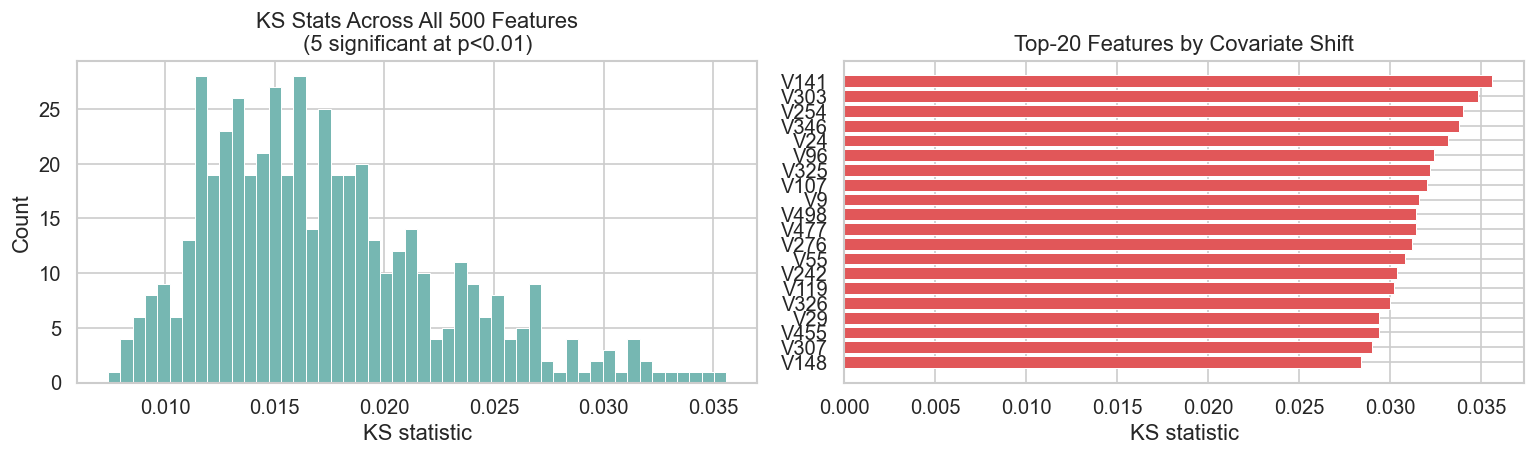

Features with significant shift (p < 0.01): 5/500
Top-5 shifted features: ['V141', 'V303', 'V254', 'V346', 'V24']


In [4]:
print('Computing per-feature KS statistics (500 features)...')
ks_stats, ks_pvals = per_feature_ks(X_train, X_test)

sig_thr = 0.01
n_sig = int((ks_pvals < sig_thr).sum())
top20_idx = np.argsort(-ks_stats)[:20]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# KS stat distribution
axes[0].hist(ks_stats, bins=50, color='#76b7b2', edgecolor='white', linewidth=0.6)
axes[0].set_xlabel('KS statistic')
axes[0].set_ylabel('Count')
axes[0].set_title(f'KS Stats Across All 500 Features\n({n_sig} significant at p<{sig_thr})')

# Top-20 most shifted features
feat_names = [f'V{j+1}' for j in top20_idx]
axes[1].barh(feat_names[::-1], ks_stats[top20_idx[::-1]],
             color='#e15759', edgecolor='white', linewidth=0.6)
axes[1].set_xlabel('KS statistic')
axes[1].set_title('Top-20 Features by Covariate Shift')

plt.tight_layout()
plt.savefig(FIGURES / '03_covariate_shift_ks.png')
plt.show()

print(f'Features with significant shift (p < {sig_thr}): {n_sig}/{N_FEAT}')
print(f'Top-5 shifted features: {[f"V{j+1}" for j in top20_idx[:5]]}')

In [5]:
print('Computing discriminator AUC...')
disc_auc_all = covariate_shift_auc(Xs_train, Xs_test)
disc_auc_top20 = covariate_shift_auc(X_train, X_test, feat_idx=top20_idx)
print(f'Discriminator AUC — all features: {disc_auc_all:.3f}  (0.5=no shift, 1.0=full shift)')
print(f'Discriminator AUC — top-20 shifted features: {disc_auc_top20:.3f}')

Computing discriminator AUC...
Discriminator AUC — all features: 0.501  (0.5=no shift, 1.0=full shift)
Discriminator AUC — top-20 shifted features: 0.544


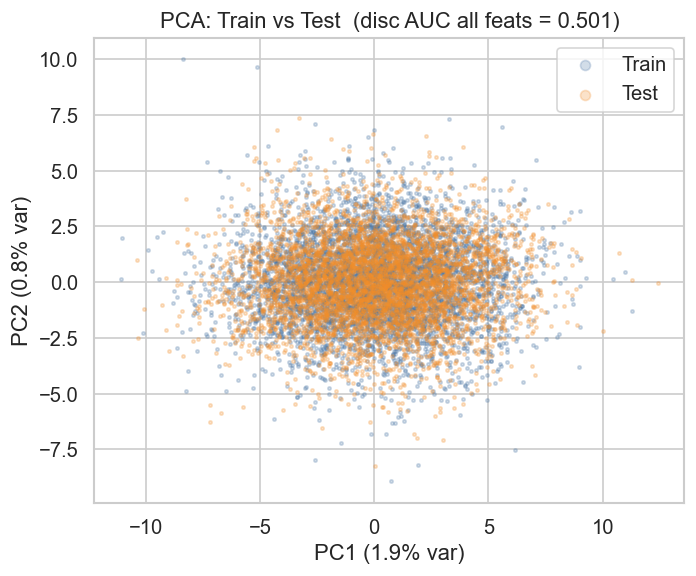

In [6]:
pca = PCA(n_components=2, random_state=0).fit(Xs_train)
Z_train = pca.transform(Xs_train)
Z_test  = pca.transform(Xs_test)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(Z_train[:, 0], Z_train[:, 1], s=4, alpha=0.25, label='Train', color='#4e79a7')
ax.scatter(Z_test[:,  0], Z_test[:,  1], s=4, alpha=0.25, label='Test',  color='#f28e2b')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title(f'PCA: Train vs Test  (disc AUC all feats = {disc_auc_all:.3f})')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig(FIGURES / '03b_pca_shift.png')
plt.show()

## 4. Class Separability on Top Features

We compute the L1 regularization path to identify the features most relevant for classification. For each top feature we compare the class-conditional distributions. Good features show clearly separated distributions for y=0 and y=1.

In [7]:
print('Computing L1 path ranking...')
l1_ranking = l1_path_ranking(Xs_train, y_train)
top10 = l1_ranking[:10]
print('Top-10 features (L1 path):', [f'V{j+1}' for j in top10])

Computing L1 path ranking...
Top-10 features (L1 path): ['V175', 'V32', 'V390', 'V345', 'V224', 'V199', 'V329', 'V161', 'V309', 'V469']


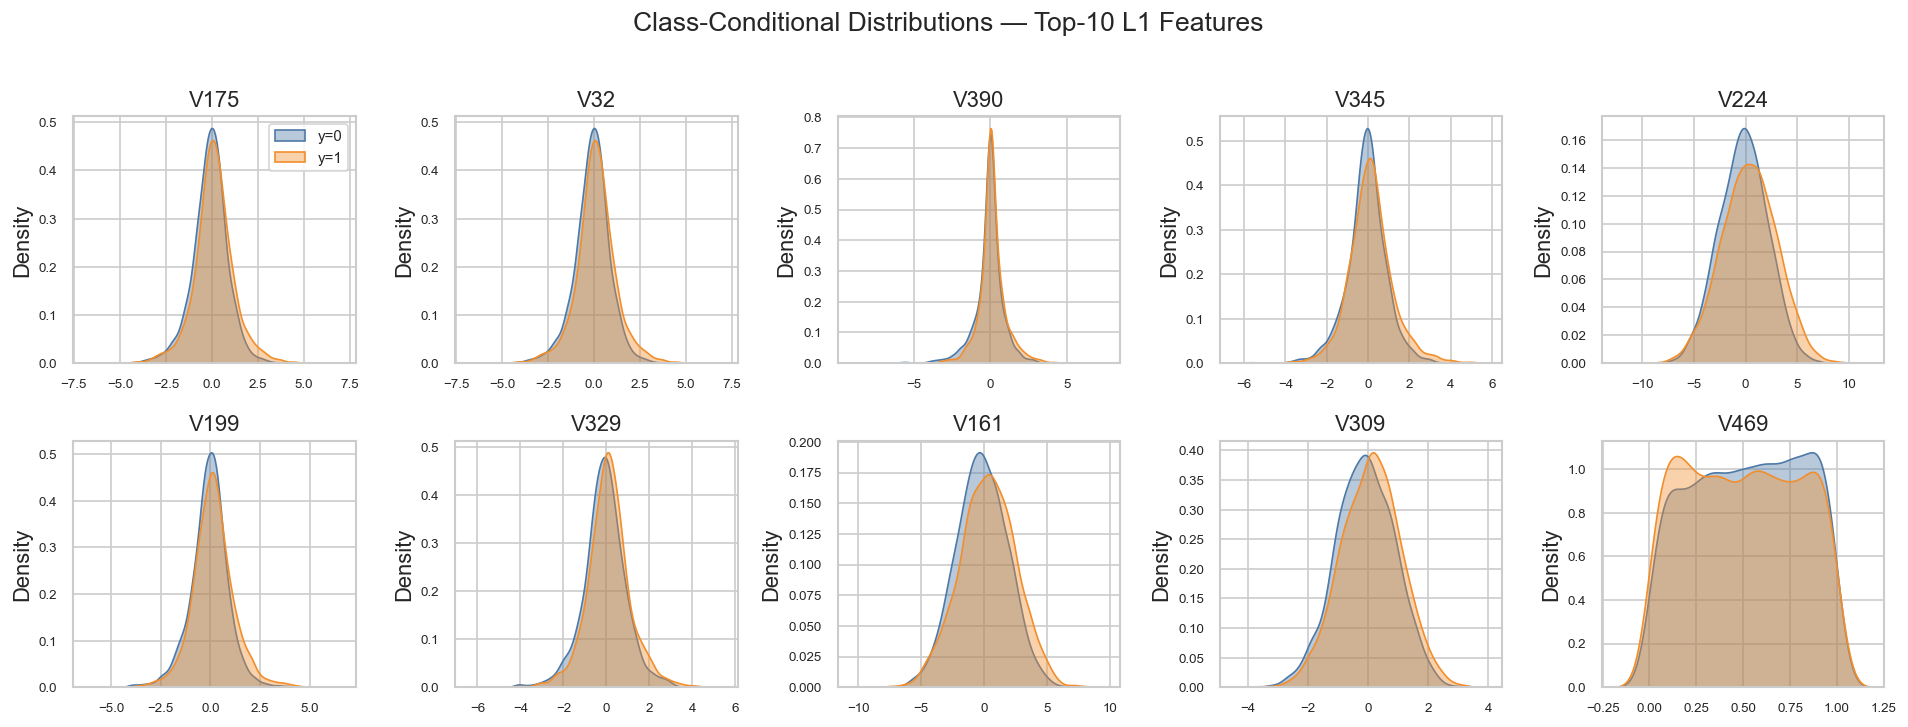

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()

for ax, j in zip(axes, top10):
    vals_0 = X_train[y_train == 0, j]
    vals_1 = X_train[y_train == 1, j]
    sns.kdeplot(vals_0, ax=ax, label='y=0', fill=True, alpha=0.4, color='#4e79a7')
    sns.kdeplot(vals_1, ax=ax, label='y=1', fill=True, alpha=0.4, color='#f28e2b')
    ax.set_title(f'V{j+1}')
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)

axes[0].legend(fontsize=9)
fig.suptitle('Class-Conditional Distributions — Top-10 L1 Features', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '04_class_sep.png')
plt.show()

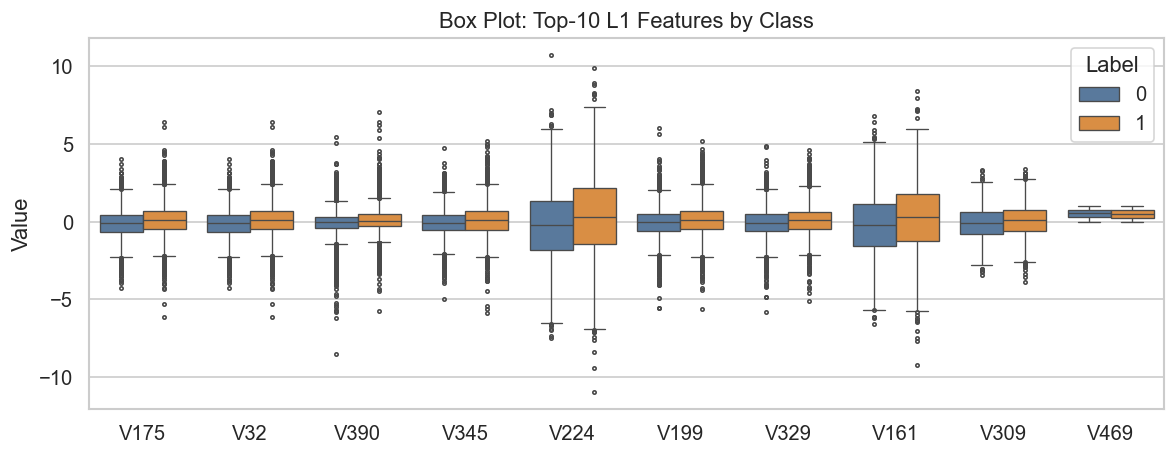

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
df_box = pd.DataFrame(
    {f'V{top10[i]+1}': X_train[:, top10[i]] for i in range(10)}
)
df_box['label'] = y_train
df_melt = df_box.melt(id_vars='label', var_name='Feature', value_name='Value')
sns.boxplot(data=df_melt, x='Feature', y='Value', hue='label',
            palette={0: '#4e79a7', 1: '#f28e2b'}, ax=ax, linewidth=0.8, fliersize=2)
ax.set_title('Box Plot: Top-10 L1 Features by Class')
ax.set_xlabel('')
ax.legend(title='Label', loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES / '04b_boxplot.png')
plt.show()

## 5. Correlation Structure

Highly correlated features are redundant — selecting both increases the NoVariables cost without improving prediction. Spearman correlation is used because feature distributions may not be normal.

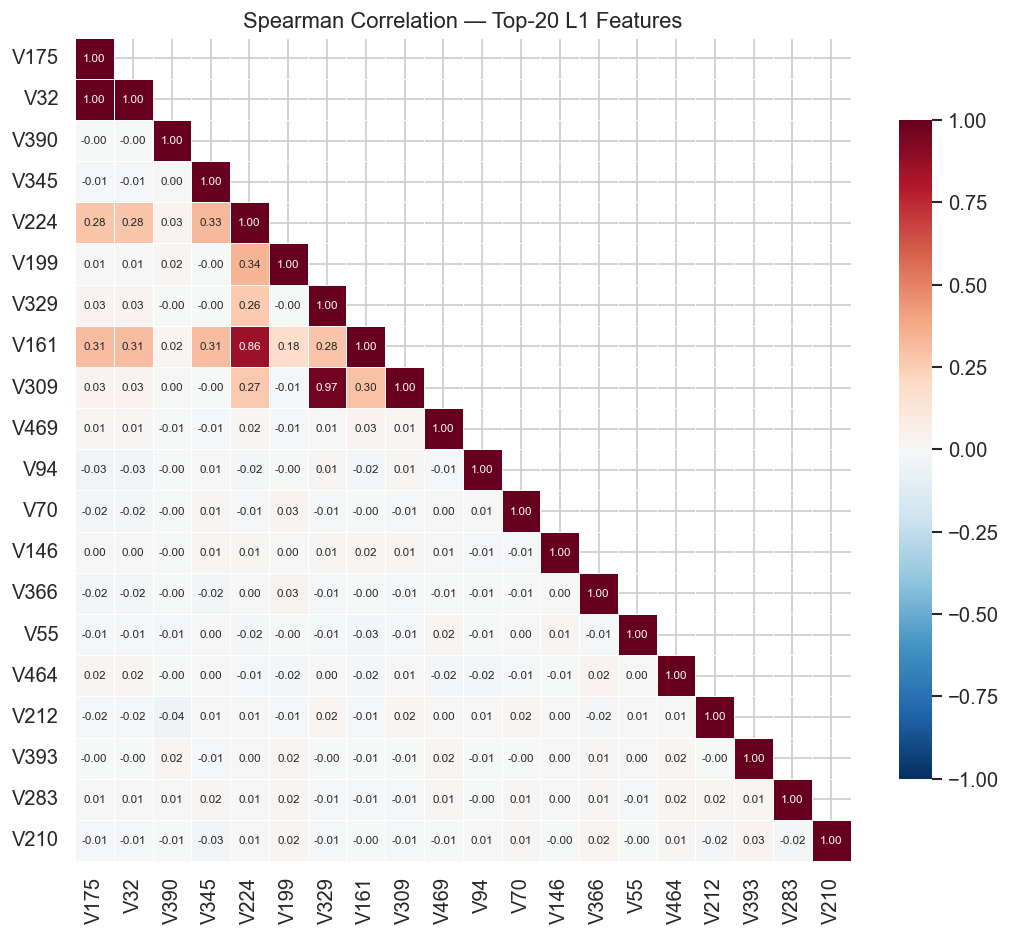

Strongly correlated pairs (|r| > 0.6):
  V175 ↔ V32:  r = 1.000
  V329 ↔ V309:  r = 0.970
  V224 ↔ V161:  r = 0.858


In [10]:
top20_l1 = l1_ranking[:20]
feat_labels = [f'V{j+1}' for j in top20_l1]

corr_mat, _ = spearmanr(X_train[:, top20_l1])
corr_df = pd.DataFrame(corr_mat, index=feat_labels, columns=feat_labels)

fig, ax = plt.subplots(figsize=(9, 8))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, linewidths=0.4, ax=ax, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
ax.set_title('Spearman Correlation — Top-20 L1 Features')
plt.tight_layout()
plt.savefig(FIGURES / '05_correlation.png')
plt.show()

# Report strongly correlated pairs
pairs = []
for i in range(len(feat_labels)):
    for j in range(i+1, len(feat_labels)):
        if abs(corr_mat[i, j]) > 0.6:
            pairs.append((feat_labels[i], feat_labels[j], corr_mat[i, j]))
if pairs:
    print('Strongly correlated pairs (|r| > 0.6):')
    for a, b, r in sorted(pairs, key=lambda x: -abs(x[2])):
        print(f'  {a} ↔ {b}:  r = {r:.3f}')
else:
    print('No strongly correlated pairs among top-20 features.')

## 6. Probability Calibration Baseline

Good calibration means that when the model predicts p=0.6, roughly 60% of those customers actually convert. For this competition, calibration matters because the threshold that maximises score (≈ 1/3 break-even) depends on the predicted probabilities being meaningful.

We evaluate a simple logistic regression baseline using 5-fold CV, then plot:
- **Calibration curve (reliability diagram)**: predicted probability vs observed fraction positive
- **Brier score**: lower is better; a perfect probability estimator scores 0

Running 5-fold CV for calibration check...


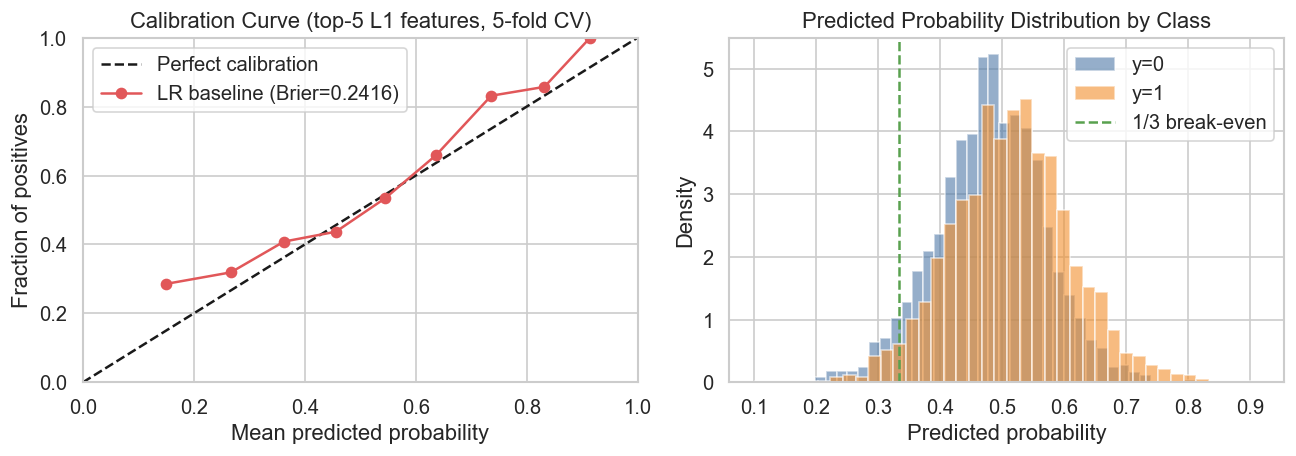

Brier score (LR, top-5 features, 5-fold CV): 0.2416
Fraction of train with p > 1/3: 0.958
Fraction of train with p > 0.5:  0.486


In [11]:
top5 = l1_ranking[:5]
lr_base = LogisticRegression(max_iter=2000, random_state=0)
skf5 = StratifiedKFold(5, shuffle=True, random_state=0)

print('Running 5-fold CV for calibration check...')
p_cv = cross_val_predict(lr_base, Xs_train[:, top5], y_train,
                          cv=skf5, method='predict_proba')[:, 1]

brier = brier_score_loss(y_train, p_cv)
frac_pos, mean_pred = calibration_curve(y_train, p_cv, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Calibration curve
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0].plot(mean_pred, frac_pos, 'o-', color='#e15759', label=f'LR baseline (Brier={brier:.4f})')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives')
axes[0].set_title('Calibration Curve (top-5 L1 features, 5-fold CV)')
axes[0].legend()
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# Predicted probability histogram
axes[1].hist(p_cv[y_train == 0], bins=40, alpha=0.6, color='#4e79a7',
             label='y=0', density=True)
axes[1].hist(p_cv[y_train == 1], bins=40, alpha=0.6, color='#f28e2b',
             label='y=1', density=True)
axes[1].axvline(1/3, color='#59a14f', linestyle='--', label='1/3 break-even')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Predicted Probability Distribution by Class')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / '06_calibration.png')
plt.show()

print(f'Brier score (LR, top-5 features, 5-fold CV): {brier:.4f}')
print(f'Fraction of train with p > 1/3: {(p_cv > 1/3).mean():.3f}')
print(f'Fraction of train with p > 0.5:  {(p_cv > 0.5).mean():.3f}')

## Summary

| Finding | Implication |
|---------|-------------|
| Label proportion ~50/50 | High positive rate → many customers score above 1/3 break-even; cap of 1 000 is likely binding |
| Near-constant features | Should be filtered before tree-based models to reduce NoVariables cost |
| Covariate shift (disc AUC) | If AUC >> 0.5, heavily shifted features should be avoided to prevent train/test gap |
| Class separability | Top L1 features show visible class separation → signal is real and usable |
| Correlation | Low cross-correlation in top-20 → features are mostly independent, L1 path is reliable |
| Calibration | Brier score and calibration curve indicate whether raw probabilities are trustworthy as decision scores |

**Next step**: `02_models.ipynb` — compare multiple models using the competition-aware CV loop.